# Fase 2 — Exploración, preprocesamiento y validación de datos

## Procedimientos sancionatorios de la Superintendencia del Medio Ambiente

**Curso:** MCDI500 — Magíster en Ciencia de Datos e Inteligencia Artificial  
**Evaluación:** Sumativa 1 — Fases 1 y 2  
**Fase:** F2 — Obtención, exploración, limpieza, transformación y validación

### Propósito de la fase

Esta fase desarrolla el diagnóstico de calidad y el procesamiento inicial del conjunto de datos utilizado en el proyecto. A diferencia de la Fase 1, en esta etapa se evaluarán y justificarán las decisiones de limpieza y transformación necesarias para obtener un conjunto de datos consistente y preparado para las fases posteriores.

El flujo de trabajo seguirá el principio metodológico de **medir antes de decidir**, conservando en todo momento la copia original almacenada en `data/raw/`.

## 1. Pipeline de procesamiento

La Fase 2 se desarrollará mediante las siguientes etapas:

1. **Obtención:** carga reproducible de la copia original del conjunto de datos.
2. **Exploración:** caracterización de dimensiones, variables, tipos y distribuciones iniciales.
3. **Diagnóstico de calidad:** evaluación de valores ausentes, duplicados, inconsistencias y posibles valores atípicos.
4. **Decisiones de tratamiento:** comparación y justificación de las alternativas de procesamiento.
5. **Limpieza:** aplicación de los tratamientos técnicamente justificados.
6. **Transformación:** adecuación de tipos y variables requeridas para el análisis posterior.
7. **Validación:** comprobación de integridad, coherencia y resultados del pipeline.
8. **Exportación:** generación del conjunto procesado en `data/processed/` sin modificar la fuente original.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

print("=== ENTORNO FASE 2 ===")
print(f"Python : {sys.version.split()[0]}")
print(f"Pandas : {pd.__version__}")
print(f"NumPy  : {np.__version__}")
print(f"Semilla: {SEED}")

=== ENTORNO FASE 2 ===
Python : 3.11.9
Pandas : 3.0.5
NumPy  : 2.4.6
Semilla: 42


## 2. Obtención del conjunto de datos

Se utiliza la misma copia original identificada en la Fase 1, descargada el **09 de septiembre de 2026** y almacenada sin modificaciones en `data/raw/`.

La carga se realiza mediante una ruta relativa para evitar dependencias asociadas al computador de un integrante del equipo.

In [2]:
RUTA_RAW = Path("../data/raw/Sancionatorios.xlsx")
RUTA_PROCESSED = Path("../data/processed")

assert RUTA_RAW.exists(), f"No se encontró el archivo: {RUTA_RAW}"

datos_raw = pd.read_excel(RUTA_RAW)

print("Dataset cargado correctamente.")
print(f"Registros : {datos_raw.shape[0]:,}")
print(f"Variables : {datos_raw.shape[1]}")

Dataset cargado correctamente.
Registros : 3,537
Variables : 19


### 2.1 Preservación de los datos originales

El DataFrame obtenido desde `data/raw/` se mantiene sin modificaciones. Las operaciones posteriores se realizarán sobre una copia independiente, permitiendo comparar el estado original con el resultado de las transformaciones y manteniendo la trazabilidad del procesamiento.

In [3]:
datos = datos_raw.copy()

print(f"Dataset original : {datos_raw.shape}")
print(f"Copia de trabajo : {datos.shape}")

Dataset original : (3537, 19)
Copia de trabajo : (3537, 19)


## 3. Exploración y diagnóstico inicial

Antes de aplicar cualquier operación de limpieza o transformación, se realiza un diagnóstico reproducible del conjunto de datos.

El objetivo de esta etapa es medir la estructura y calidad inicial del dataset mediante indicadores objetivos: dimensiones, tipos de datos, cantidad y porcentaje de valores ausentes, cardinalidad y registros duplicados.

Estas mediciones serán utilizadas posteriormente para justificar las decisiones de tratamiento.

In [5]:
def diagnosticar_dataset(datos):
    """
    Genera un diagnóstico estructural y de calidad sin modificar
    el DataFrame recibido.

    Parámetros
    ----------
    datos : pandas.DataFrame
        Conjunto de datos que se desea diagnosticar.

    Retorna
    -------
    pandas.DataFrame
        Tabla resumen con tipo, cantidad de valores no nulos,
        nulos, porcentaje de nulos y cardinalidad por variable.
    """
    df = datos.copy()

    resumen = pd.DataFrame({
        "Variable": df.columns,
        "Tipo": df.dtypes.astype(str).values,
        "No_nulos": df.notna().sum().values,
        "Nulos": df.isna().sum().values,
        "Porcentaje_nulos": (df.isna().mean().values * 100),
        "Valores_unicos": df.nunique(dropna=True).values
    })

    return resumen

In [6]:
diagnostico = diagnosticar_dataset(datos)

diagnostico

,Variable,Tipo,No_nulos,Nulos,Porcentaje_nulos,Valores_unicos
0,ProcesoSancionId,int64,3537,0,0.000000,3476
1,Expediente,str,3537,0,0.000000,3476
2,ProcesoSancionTipoNombre,str,3537,0,0.000000,4
3,ProcesoSancionEstado,str,3537,0,0.000000,7
4,FechaInicio,str,3537,0,0.000000,1599
5,FechaTermino,str,2106,1431,40.458015,1216
6,ConfirmaPdC,str,3537,0,0.000000,2
7,MultaTotalUTA,float64,1298,2239,63.302234,374
8,LinkSNIFA,str,3537,0,0.000000,3476
9,UnidadFiscalizableId,int64,3537,0,0.000000,3196


In [7]:
total_duplicados = datos.duplicated().sum()

print("=== DIAGNÓSTICO GENERAL ===")
print(f"Filas                   : {datos.shape[0]:,}")
print(f"Columnas                : {datos.shape[1]}")
print(f"Registros duplicados    : {total_duplicados:,}")
print(f"Variables con nulos     : {(datos.isna().sum() > 0).sum()}")
print(f"Total de valores nulos  : {datos.isna().sum().sum():,}")

=== DIAGNÓSTICO GENERAL ===
Filas                   : 3,537
Columnas                : 19
Registros duplicados    : 0
Variables con nulos     : 6
Total de valores nulos  : 3,779


### 3.1 Identificación del universo de análisis de `MultaTotalUTA`

La proporción de valores ausentes de `MultaTotalUTA` debe interpretarse considerando el estado administrativo del procedimiento.

Antes de definir cualquier filtro se revisarán las categorías existentes en `ProcesoSancionEstado`, evitando asumir de antemano qué registros constituyen el universo pertinente para el análisis de multas.

In [8]:
estados = (
    datos["ProcesoSancionEstado"]
    .value_counts(dropna=False)
    .rename_axis("Estado")
    .reset_index(name="Cantidad")
)

estados

,Estado,Cantidad
0,Terminado - Sanción,1094
1,En curso,920
2,Terminado - PDC Satisfactorio,783
3,Programa de Cumplimiento en ejecución,563
4,Terminado - Archivado,83
5,Terminado - Absolución,77
6,Suspendido,17


In [9]:
resumen_multa_estado = (
    datos.groupby("ProcesoSancionEstado", dropna=False)
    .agg(
        Registros=("ProcesoSancionId", "size"),
        Multas_presentes=("MultaTotalUTA", "count"),
        Multas_nulas=("MultaTotalUTA", lambda x: x.isna().sum())
    )
    .reset_index()
)

resumen_multa_estado["Porcentaje_nulos"] = (
    resumen_multa_estado["Multas_nulas"]
    / resumen_multa_estado["Registros"]
    * 100
)

resumen_multa_estado

,ProcesoSancionEstado,Registros,Multas_presentes,Multas_nulas,Porcentaje_nulos
0,En curso,920,304,616,66.956522
1,Programa de Cumplimiento en ejecución,563,1,562,99.822380
2,Suspendido,17,0,17,100.000000
3,Terminado - Absolución,77,2,75,97.402597
4,Terminado - Archivado,83,0,83,100.000000
5,Terminado - PDC Satisfactorio,783,7,776,99.106003
6,Terminado - Sanción,1094,984,110,10.054845


### 3.2 Delimitación del universo de análisis de multas

El diagnóstico evidencia que la proporción de valores ausentes de `MultaTotalUTA` depende significativamente del estado del procedimiento sancionatorio.

En el conjunto completo, `MultaTotalUTA` presenta 2.239 valores ausentes sobre 3.537 registros, equivalentes aproximadamente al **63,30 %**. Sin embargo, este porcentaje considera conjuntamente procedimientos que se encuentran en distintos estados administrativos.

Al segmentar los registros según `ProcesoSancionEstado`, se observa que el estado `Terminado - Sanción` contiene **1.094 procedimientos**, de los cuales **984 presentan un valor en `MultaTotalUTA` y 110 no lo presentan**, resultando en un **10,05 % de valores ausentes**.

Este resultado demuestra que interpretar el 63,30 % de ausencia como un problema general de calidad sería incorrecto, ya que una parte importante corresponde a procedimientos cuyo estado no representa una sanción terminada.

Por esta razón, para estudiar los factores asociados a la magnitud de las multas se define como universo inicial de análisis la sub-base correspondiente a procedimientos con estado `Terminado - Sanción`.

Los 110 valores ausentes que permanecen dentro de este universo no serán eliminados ni imputados automáticamente. Su tratamiento será evaluado posteriormente a partir de evidencia adicional.

## 4. Construcción del universo inicial de análisis

A partir del diagnóstico anterior se construye una sub-base correspondiente a procedimientos con estado `Terminado - Sanción`.

La selección se implementa mediante una función con parámetros explícitos, evitando modificar el DataFrame original y permitiendo reutilizar y verificar la operación.

In [10]:
def filtrar_por_estado(df, estado):
    """
    Retorna una copia del DataFrame filtrada por estado del procedimiento.

    Parámetros
    ----------
    df : pandas.DataFrame
        Conjunto de datos de entrada.
    estado : str
        Estado del procedimiento que se desea seleccionar.

    Retorna
    -------
    pandas.DataFrame
        Copia del conjunto filtrado.
    """
    return df.loc[
        df["ProcesoSancionEstado"] == estado
    ].copy()

In [11]:
datos_sancion = filtrar_por_estado(
    datos,
    "Terminado - Sanción"
)

print("=== UNIVERSO INICIAL DE ANÁLISIS ===")
print(f"Dataset completo          : {len(datos):,} registros")
print(f"Terminado - Sanción       : {len(datos_sancion):,} registros")
print(f"MultaTotalUTA presentes   : {datos_sancion['MultaTotalUTA'].notna().sum():,}")
print(f"MultaTotalUTA ausentes    : {datos_sancion['MultaTotalUTA'].isna().sum():,}")
print(
    f"Porcentaje ausente        : "
    f"{datos_sancion['MultaTotalUTA'].isna().mean() * 100:.2f}%"
)

=== UNIVERSO INICIAL DE ANÁLISIS ===
Dataset completo          : 3,537 registros
Terminado - Sanción       : 1,094 registros
MultaTotalUTA presentes   : 984
MultaTotalUTA ausentes    : 110
Porcentaje ausente        : 10.05%


In [12]:
assert len(datos_sancion) == 1094, \
    "La cantidad de registros filtrados no coincide con lo esperado."

assert (
    datos_sancion["ProcesoSancionEstado"] == "Terminado - Sanción"
).all(), "La sub-base contiene estados diferentes a Terminado - Sanción."

assert len(datos) == 3537, \
    "El dataset original fue modificado durante el procesamiento."

print("Validaciones superadas correctamente.")

Validaciones superadas correctamente.


## 5. Investigación de valores ausentes en MultaTotalUTA

Luego de delimitar el universo inicial a los procedimientos con estado `Terminado - Sanción`, permanecen 110 registros sin valor en `MultaTotalUTA`.

Antes de decidir su tratamiento se analizarán sus características utilizando las variables disponibles en el conjunto de datos. El objetivo es determinar si la ausencia presenta algún patrón observable y evitar la eliminación o imputación automática de registros sin una justificación previa.

In [13]:
sanciones_sin_multa = datos_sancion.loc[
    datos_sancion["MultaTotalUTA"].isna()
].copy()

print("=== SANCIONES SIN MultaTotalUTA ===")
print(f"Cantidad de registros: {len(sanciones_sin_multa):,}")
print(f"Porcentaje del universo Terminado - Sanción: "
      f"{len(sanciones_sin_multa) / len(datos_sancion) * 100:.2f}%")

=== SANCIONES SIN MultaTotalUTA ===
Cantidad de registros: 110
Porcentaje del universo Terminado - Sanción: 10.05%


In [14]:
columnas_revision = [
    "Expediente",
    "ProcesoSancionTipoNombre",
    "FechaInicio",
    "FechaTermino",
    "ConfirmaPdC",
    "MultaTotalUTA",
    "Nombre",
    "RegionNombre",
    "CategoriaEconomicaNombre"
]

sanciones_sin_multa[columnas_revision].head(15)

,Expediente,ProcesoSancionTipoNombre,FechaInicio,FechaTermino,ConfirmaPdC,MultaTotalUTA,Nombre,RegionNombre,CategoriaEconomicaNombre
12,D-002-2013,Denuncia,06-03-2013,17-06-2013,No,NaN,ALMACENAJE PELIGROSOSPLATAFORMA DE ALMACENAMIE...,Región de Tarapacá,Transportes y almacenajes
60,F-030-2013,Fiscalización,27-11-2013,27-03-2014,No,NaN,*RESERVADO*,Región de la Araucanía,Vivienda e Inmobiliarios
61,F-031-2013,Fiscalización,27-11-2013,24-02-2014,No,NaN,*RESERVADO*,Región de la Araucanía,Vivienda e Inmobiliarios
62,F-037-2013,Fiscalización,27-11-2013,30-12-2013,No,NaN,LEÑERÍAESTABLECIMIENTO 503,Región de la Araucanía,Equipamiento
64,F-035-2013,Fiscalización,27-11-2013,25-02-2014,No,NaN,*RESERVADO*,Región de la Araucanía,Vivienda e Inmobiliarios
66,F-033-2013,Fiscalización,27-11-2013,24-02-2014,No,NaN,LEÑERÍAESTABLECIMIENTO ESPINOZA,Región de la Araucanía,Equipamiento
76,F-006-2014,Fiscalización,18-02-2014,24-11-2014,No,NaN,CENTRO COMERCIALELADIO EUFRACIO ALVIAL VERGARA...,Región de la Araucanía,Equipamiento
77,D-002-2014,Denuncia,19-02-2014,07-07-2020,No,NaN,PLAN REGULADOR COMUNAL DE PUCHUNCAVI,Región de Valparaíso,Otras categorías
109,F-034-2014,Fiscalización,02-05-2014,22-08-2014,No,NaN,*RESERVADO*,Región de la Araucanía,Vivienda e Inmobiliarios
111,F-036-2014,Fiscalización,02-05-2014,22-08-2014,No,NaN,LEÑERÍAESTABLECIMIENTO 511,Región de la Araucanía,Equipamiento


In [15]:
sanciones_sin_multa["ConfirmaPdC"].value_counts(dropna=False)

ConfirmaPdC
No    110
Name: count, dtype: int64

In [16]:
sanciones_sin_multa["ProcesoSancionTipoNombre"].value_counts(dropna=False)

ProcesoSancionTipoNombre
Denuncia         61
Fiscalización    41
Autodenuncia      8
Name: count, dtype: int64

In [17]:
sanciones_sin_multa["CategoriaEconomicaNombre"].value_counts(dropna=False)

CategoriaEconomicaNombre
Equipamiento                     67
Vivienda e Inmobiliarios         13
Otras categorías                  8
Agroindustrias                    7
Instalación fabril                5
Transportes y almacenajes         3
Forestal                          2
Minería                           2
Infraestructura de Transporte     1
Infraestructura Portuaria         1
Saneamiento Ambiental             1
Name: count, dtype: int64

In [18]:
comparacion_multa = datos_sancion.copy()

comparacion_multa["EstadoMulta"] = np.where(
    comparacion_multa["MultaTotalUTA"].isna(),
    "Sin valor de multa",
    "Con valor de multa"
)

pd.crosstab(
    comparacion_multa["ConfirmaPdC"],
    comparacion_multa["EstadoMulta"],
    margins=True
)

EstadoMulta,Con valor de multa,Sin valor de multa,All
ConfirmaPdC,,,
No,983,110,1093
Sí,1,0,1
All,984,110,1094


In [19]:
pd.crosstab(
    comparacion_multa["ProcesoSancionTipoNombre"],
    comparacion_multa["EstadoMulta"],
    margins=True
)

EstadoMulta,Con valor de multa,Sin valor de multa,All
ProcesoSancionTipoNombre,,,
Autodenuncia,0,8,8
Denuncia,742,61,803
Fiscalización,241,41,282
Programa de Cumplimiento,1,0,1
All,984,110,1094


In [20]:
multas_cero = (datos_sancion["MultaTotalUTA"] == 0).sum()
multas_negativas = (datos_sancion["MultaTotalUTA"] < 0).sum()

print("=== COMPROBACIONES DE MultaTotalUTA ===")
print(f"Valores nulos     : {datos_sancion['MultaTotalUTA'].isna().sum():,}")
print(f"Multas iguales a 0: {multas_cero:,}")
print(f"Multas negativas  : {multas_negativas:,}")

=== COMPROBACIONES DE MultaTotalUTA ===
Valores nulos     : 110
Multas iguales a 0: 0
Multas negativas  : 0


### 5.1 Decisión de tratamiento de valores ausentes en MultaTotalUTA

El análisis de los 110 procedimientos con estado `Terminado - Sanción` y valor ausente en `MultaTotalUTA` no evidencia una regla que permita reconstruir de manera confiable la magnitud de la multa.

La variable `ConfirmaPdC` no explica por sí sola la ausencia, dado que 983 de los 984 procedimientos que sí poseen valor de multa también presentan `ConfirmaPdC = No`.

Los registros sin valor de multa se distribuyen además entre distintos tipos de procedimiento: 8 corresponden a Autodenuncia, 61 a Denuncia y 41 a Fiscalización. Por lo tanto, la ausencia tampoco se encuentra restringida a un único tipo de procedimiento.

Adicionalmente, dentro del universo `Terminado - Sanción` no se observan multas iguales a cero ni valores negativos. En consecuencia, no existe evidencia que permita interpretar los valores ausentes como multas de valor cero.

Dado que el objetivo del proyecto es estudiar factores asociados a la **magnitud de las multas**, los registros sin un valor observado en `MultaTotalUTA` no permiten cuantificar la variable objetivo. Se decide, por tanto, excluir estos registros exclusivamente del conjunto analítico destinado al estudio de magnitud de multas, sin eliminarlos del conjunto original ni imputar valores artificiales.

Esta decisión reduce el universo analítico de 1.094 a 984 registros y será registrada como una transformación explícita y reproducible.

## 6. Construcción del conjunto analítico de multas

A partir de la decisión documentada, se construye el conjunto destinado al análisis de magnitud de multas. La operación se encapsula en una función para mantener un procesamiento explícito, reutilizable y verificable.

In [21]:
def construir_base_multas(df):
    """
    Construye la base analítica de multas a partir de procedimientos
    con estado Terminado - Sanción y MultaTotalUTA observada.

    El DataFrame original no es modificado.
    """
    resultado = df.loc[
        (df["ProcesoSancionEstado"] == "Terminado - Sanción") &
        (df["MultaTotalUTA"].notna())
    ].copy()

    return resultado

In [22]:
datos_multas = construir_base_multas(datos)

print("=== CONSTRUCCIÓN DEL CONJUNTO ANALÍTICO ===")
print(f"Dataset original                  : {len(datos):,}")
print(f"Terminado - Sanción               : {len(datos_sancion):,}")
print(f"Sin MultaTotalUTA en ese universo : {datos_sancion['MultaTotalUTA'].isna().sum():,}")
print(f"Conjunto analítico resultante     : {len(datos_multas):,}")

=== CONSTRUCCIÓN DEL CONJUNTO ANALÍTICO ===
Dataset original                  : 3,537
Terminado - Sanción               : 1,094
Sin MultaTotalUTA en ese universo : 110
Conjunto analítico resultante     : 984


In [23]:
assert len(datos_multas) == 984, \
    "La cantidad de registros del conjunto analítico no es la esperada."

assert datos_multas["MultaTotalUTA"].notna().all(), \
    "Persisten valores ausentes en MultaTotalUTA."

assert (datos_multas["MultaTotalUTA"] > 0).all(), \
    "Se detectaron multas iguales o inferiores a cero."

assert (
    datos_multas["ProcesoSancionEstado"] == "Terminado - Sanción"
).all(), "Existen procedimientos fuera del estado seleccionado."

assert len(datos) == 3537, \
    "El conjunto de trabajo original fue modificado."

print("Todas las validaciones del conjunto analítico fueron superadas.")

Todas las validaciones del conjunto analítico fueron superadas.


## 7. Diagnóstico de calidad del conjunto analítico

Una vez delimitado el universo de 984 procedimientos con estado `Terminado - Sanción` y valor observado en `MultaTotalUTA`, se realiza un nuevo diagnóstico sobre el conjunto analítico.

Este diagnóstico permite evaluar la calidad de las variables que potencialmente participarán en el análisis posterior, considerando tipos de datos, valores ausentes, cardinalidad y duplicados.

Las mediciones obtenidas serán utilizadas para determinar qué transformaciones resultan necesarias, evitando aplicar tratamientos automáticos sin evidencia previa.

In [24]:
diagnostico_multas = diagnosticar_dataset(datos_multas)

diagnostico_multas

,Variable,Tipo,No_nulos,Nulos,Porcentaje_nulos,Valores_unicos
0,ProcesoSancionId,int64,984,0,0.000000,963
1,Expediente,str,984,0,0.000000,963
2,ProcesoSancionTipoNombre,str,984,0,0.000000,3
3,ProcesoSancionEstado,str,984,0,0.000000,1
4,FechaInicio,str,984,0,0.000000,663
5,FechaTermino,str,982,2,0.203252,722
6,ConfirmaPdC,str,984,0,0.000000,2
7,MultaTotalUTA,float64,984,0,0.000000,300
8,LinkSNIFA,str,984,0,0.000000,963
9,UnidadFiscalizableId,int64,984,0,0.000000,935


In [25]:
variables_con_nulos = (
    diagnostico_multas
    .loc[diagnostico_multas["Nulos"] > 0]
    .sort_values("Porcentaje_nulos", ascending=False)
)

variables_con_nulos

,Variable,Tipo,No_nulos,Nulos,Porcentaje_nulos,Valores_unicos
13,Latitud,float64,975,9,0.914634,922
14,Longitud,float64,976,8,0.813008,924
15,CategoriaEconomicaNombre,str,978,6,0.609756,15
16,SubCategoriaEconomicaNombre,str,978,6,0.609756,91
5,FechaTermino,str,982,2,0.203252,722


In [26]:
print("=== CALIDAD DEL CONJUNTO ANALÍTICO ===")
print(f"Registros             : {len(datos_multas):,}")
print(f"Variables             : {datos_multas.shape[1]}")
print(f"Duplicados completos  : {datos_multas.duplicated().sum():,}")
print(f"Variables con nulos   : {(datos_multas.isna().sum() > 0).sum()}")
print(f"Valores nulos totales : {datos_multas.isna().sum().sum():,}")

=== CALIDAD DEL CONJUNTO ANALÍTICO ===
Registros             : 984
Variables             : 19
Duplicados completos  : 0
Variables con nulos   : 5
Valores nulos totales : 31


## 8. Validación de identificadores

Además de los registros completamente duplicados, se evalúa la unicidad de los identificadores principales del conjunto de datos.

Esta comprobación permite detectar posibles repeticiones de procedimientos que no serían identificadas mediante una búsqueda de filas completamente idénticas.

In [27]:
duplicados_id = datos_multas["ProcesoSancionId"].duplicated().sum()
duplicados_expediente = datos_multas["Expediente"].duplicated().sum()

print("=== VALIDACIÓN DE IDENTIFICADORES ===")
print(f"ProcesoSancionId duplicados : {duplicados_id:,}")
print(f"Expediente duplicados       : {duplicados_expediente:,}")
print(f"ProcesoSancionId únicos     : {datos_multas['ProcesoSancionId'].nunique():,}")
print(f"Expedientes únicos          : {datos_multas['Expediente'].nunique():,}")

=== VALIDACIÓN DE IDENTIFICADORES ===
ProcesoSancionId duplicados : 21
Expediente duplicados       : 21
ProcesoSancionId únicos     : 963
Expedientes únicos          : 963


## 9. Exploración de la variable objetivo MultaTotalUTA

La variable `MultaTotalUTA` representa la magnitud de la multa y constituye la variable central del proyecto.

Antes de aplicar transformaciones o evaluar posibles valores atípicos, se examinan sus principales estadísticos descriptivos y su distribución. Los valores extremos no serán considerados automáticamente como errores, ya que pueden representar sanciones reales de elevada magnitud.

In [28]:
datos_multas["MultaTotalUTA"].describe()

count      984.00000
mean       211.30436
std        987.10711
min          0.20000
25%          2.00000
50%          7.60000
75%         38.00000
max      14745.00000
Name: MultaTotalUTA, dtype: float64

In [29]:
percentiles_multa = datos_multas["MultaTotalUTA"].quantile(
    [0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]
)

percentiles_multa

0.00        0.200
0.25        2.000
0.50        7.600
0.75       38.000
0.90      201.500
0.95      742.950
0.99     3675.605
1.00    14745.000
Name: MultaTotalUTA, dtype: float64

In [31]:
import matplotlib
import matplotlib.pyplot as plt

print(f"Matplotlib: {matplotlib.__version__}")

Matplotlib: 3.11.2


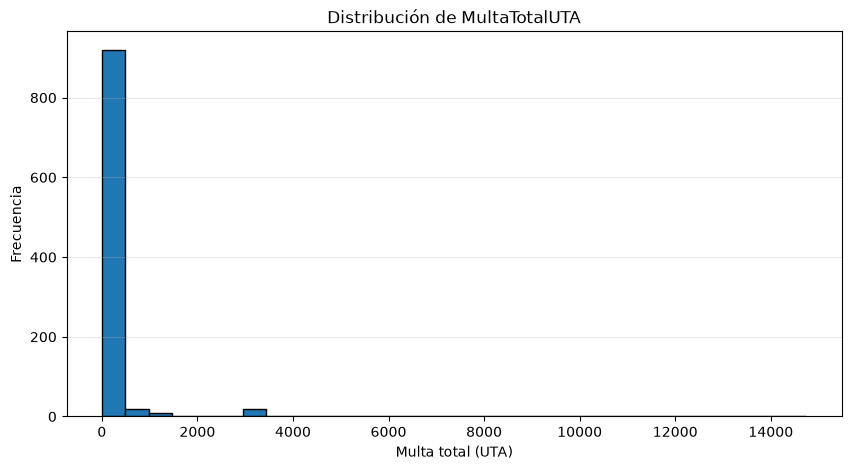

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    datos_multas["MultaTotalUTA"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución de MultaTotalUTA")
plt.xlabel("Multa total (UTA)")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)

plt.show()

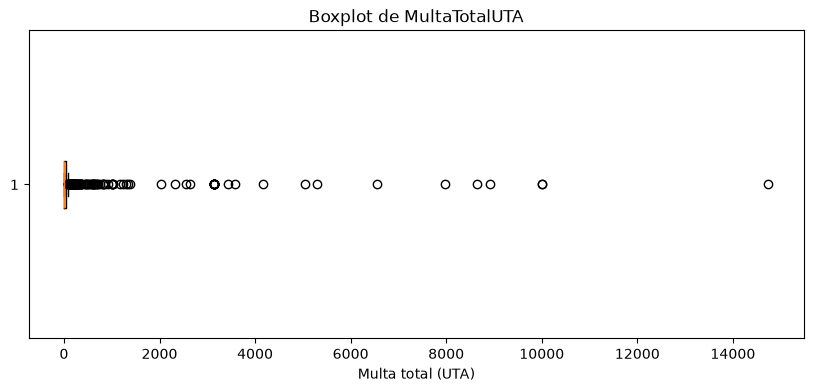

In [34]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    datos_multas["MultaTotalUTA"],
    orientation="horizontal"
)

plt.title("Boxplot de MultaTotalUTA")
plt.xlabel("Multa total (UTA)")
plt.show()

### 9.2 Distribución inicial y posibles valores atípicos

La distribución de `MultaTotalUTA` presenta una marcada asimetría positiva. La mediana corresponde a 7,6 UTA, mientras que el percentil 90 alcanza 201,5 UTA, el percentil 99 aproximadamente 3.675,61 UTA y el máximo observado 14.745 UTA.

La diferencia entre las medidas centrales y los percentiles superiores evidencia la existencia de una cola derecha extensa y de observaciones que pueden ser clasificadas estadísticamente como valores atípicos.

Sin embargo, un valor estadísticamente atípico no constituye necesariamente un error de datos. En el contexto de procedimientos sancionatorios, multas de elevada magnitud pueden representar sanciones reales y relevantes para la pregunta de investigación.

Por esta razón, en esta etapa los valores extremos serán identificados y cuantificados, pero no eliminados automáticamente. Cualquier decisión posterior deberá considerar tanto criterios estadísticos como la naturaleza del fenómeno analizado.

## 10. Detección de valores atípicos mediante rango intercuartílico

Para identificar observaciones estadísticamente atípicas en `MultaTotalUTA` se utiliza el criterio del rango intercuartílico (IQR).

El IQR corresponde a la diferencia entre el tercer y primer cuartil. Se consideran potencialmente atípicas aquellas observaciones ubicadas bajo `Q1 - 1,5 × IQR` o sobre `Q3 + 1,5 × IQR`.

Este procedimiento se utiliza como mecanismo de diagnóstico y no como criterio automático de eliminación, debido a que multas elevadas pueden constituir observaciones válidas y relevantes para el fenómeno estudiado.

In [35]:
q1 = datos_multas["MultaTotalUTA"].quantile(0.25)
q3 = datos_multas["MultaTotalUTA"].quantile(0.75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print("=== CRITERIO IQR ===")
print(f"Q1              : {q1:.2f} UTA")
print(f"Q3              : {q3:.2f} UTA")
print(f"IQR             : {iqr:.2f} UTA")
print(f"Límite inferior : {limite_inferior:.2f} UTA")
print(f"Límite superior : {limite_superior:.2f} UTA")

=== CRITERIO IQR ===
Q1              : 2.00 UTA
Q3              : 38.00 UTA
IQR             : 36.00 UTA
Límite inferior : -52.00 UTA
Límite superior : 92.00 UTA


In [36]:
mask_atipicos = (
    (datos_multas["MultaTotalUTA"] < limite_inferior) |
    (datos_multas["MultaTotalUTA"] > limite_superior)
)

cantidad_atipicos = mask_atipicos.sum()
porcentaje_atipicos = cantidad_atipicos / len(datos_multas) * 100

print("=== RESULTADO DETECCIÓN IQR ===")
print(f"Registros analizados : {len(datos_multas):,}")
print(f"Valores atípicos     : {cantidad_atipicos:,}")
print(f"Porcentaje atípicos  : {porcentaje_atipicos:.2f}%")

=== RESULTADO DETECCIÓN IQR ===
Registros analizados : 984
Valores atípicos     : 149
Porcentaje atípicos  : 15.14%


In [37]:
atipicos_multa = (
    datos_multas.loc[
        mask_atipicos,
        [
            "Expediente",
            "MultaTotalUTA",
            "ProcesoSancionTipoNombre",
            "RegionNombre",
            "CategoriaEconomicaNombre",
            "Nombre"
        ]
    ]
    .sort_values("MultaTotalUTA", ascending=False)
)

atipicos_multa.head(15)

,Expediente,MultaTotalUTA,ProcesoSancionTipoNombre,RegionNombre,CategoriaEconomicaNombre,Nombre
50,F-025-2013,14745.0,Fiscalización,Región de Atacama,Minería,CASERONES
868,D-018-2019,10000.0,Denuncia,Región de Atacama,Minería,CASERONES
1273,D-099-2020,10000.0,Denuncia,Región de Antofagasta,Minería,MINERA ESCONDIDA
827,D-103-2018,8914.0,Denuncia,Región de los Lagos,Pesca y Acuicultura,CES PUNTA REDONDA (RNA 102833)
35,D-015-2013,8640.4,Denuncia,Región del Biobío,Energía,CT BOCAMINA
716,F-009-2018,7976.0,Fiscalización,Región de Valparaíso,Minería,MINA CARDENILLA
134,F-054-2014,6554.0,Fiscalización,Región Metropolitana,Minería,LOS BRONCES - ANGLO AMERICAN SUR S.A.
39,F-019-2013,5299.4,Fiscalización,Región de Valparaíso,Minería,MINA EL SOLDADO
246,D-018-2015,5049.0,Denuncia,Región de Atacama,Minería,CANDELARIA
2009,D-207-2022,4162.4,Denuncia,Región de Atacama,Minería,CANDELARIA-OJOS DEL SALADO


### 10.1 Visualización complementaria en escala logarítmica

Debido a la marcada asimetría de `MultaTotalUTA`, la representación en escala lineal dificulta observar la distribución de las multas de menor magnitud.

Se incorpora una visualización complementaria utilizando el logaritmo natural de la multa. Esta transformación se emplea con fines exploratorios y no reemplaza los valores originales del conjunto de datos.

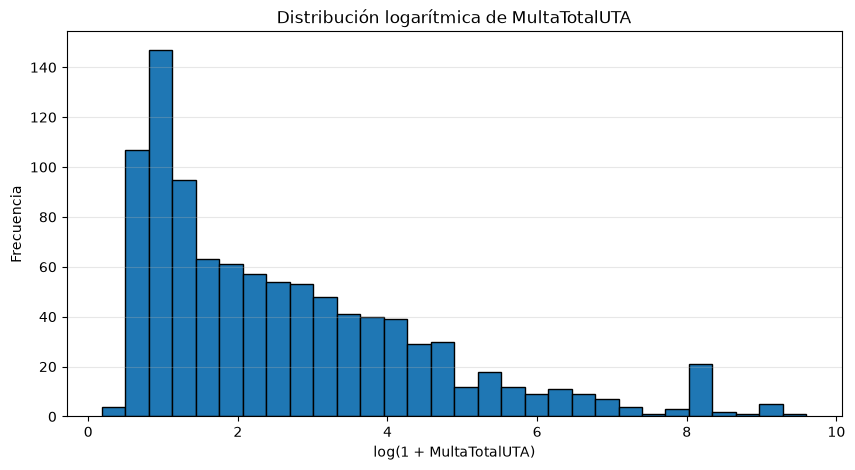

In [38]:
multa_log = np.log1p(datos_multas["MultaTotalUTA"])

plt.figure(figsize=(10, 5))

plt.hist(
    multa_log,
    bins=30,
    edgecolor="black"
)

plt.title("Distribución logarítmica de MultaTotalUTA")
plt.xlabel("log(1 + MultaTotalUTA)")
plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [39]:
print("=== RESULTADO DETECCIÓN IQR ===")
print(f"Registros analizados : {len(datos_multas):,}")
print(f"Valores atípicos     : {cantidad_atipicos:,}")
print(f"Porcentaje atípicos  : {porcentaje_atipicos:.2f}%")

=== RESULTADO DETECCIÓN IQR ===
Registros analizados : 984
Valores atípicos     : 149
Porcentaje atípicos  : 15.14%


In [40]:
atipicos_multa.head(15)

,Expediente,MultaTotalUTA,ProcesoSancionTipoNombre,RegionNombre,CategoriaEconomicaNombre,Nombre
50,F-025-2013,14745.0,Fiscalización,Región de Atacama,Minería,CASERONES
868,D-018-2019,10000.0,Denuncia,Región de Atacama,Minería,CASERONES
1273,D-099-2020,10000.0,Denuncia,Región de Antofagasta,Minería,MINERA ESCONDIDA
827,D-103-2018,8914.0,Denuncia,Región de los Lagos,Pesca y Acuicultura,CES PUNTA REDONDA (RNA 102833)
35,D-015-2013,8640.4,Denuncia,Región del Biobío,Energía,CT BOCAMINA
716,F-009-2018,7976.0,Fiscalización,Región de Valparaíso,Minería,MINA CARDENILLA
134,F-054-2014,6554.0,Fiscalización,Región Metropolitana,Minería,LOS BRONCES - ANGLO AMERICAN SUR S.A.
39,F-019-2013,5299.4,Fiscalización,Región de Valparaíso,Minería,MINA EL SOLDADO
246,D-018-2015,5049.0,Denuncia,Región de Atacama,Minería,CANDELARIA
2009,D-207-2022,4162.4,Denuncia,Región de Atacama,Minería,CANDELARIA-OJOS DEL SALADO


### 10.2 Decisión de tratamiento de valores atípicos

La aplicación del criterio del rango intercuartílico (IQR) identifica **149 observaciones estadísticamente atípicas**, equivalentes al **15,14 %** de los 984 registros del conjunto analítico.

La inspección de las observaciones de mayor magnitud muestra que estos valores se encuentran asociados a expedientes, regiones, categorías económicas y unidades fiscalizables identificables. Entre los valores superiores se observan procedimientos vinculados principalmente a actividades como minería, pesca y acuicultura, energía y agroindustrias.

Por lo anterior, la condición de valor atípico estadístico no constituye evidencia suficiente para considerar estas observaciones como errores. Además, su eliminación podría afectar precisamente el fenómeno que se busca estudiar: los factores asociados a multas de mayor magnitud.

En consecuencia, **se decide conservar los 149 valores identificados mediante IQR**, manteniendo `MultaTotalUTA` en su escala original. Complementariamente, se utiliza `log(1 + MultaTotalUTA)` como transformación exploratoria para facilitar la visualización de una distribución fuertemente asimétrica, sin reemplazar ni alterar los valores originales.

Esta decisión permite preservar la variabilidad real del fenómeno y mantener trazabilidad respecto del conjunto de datos original.

## 11. Revisión y transformación de tipos de datos

Los tipos detectados automáticamente por Pandas representan la forma en que los datos fueron almacenados, pero no necesariamente su significado analítico.

Por esta razón, se revisan las variables considerando tanto su tipo técnico como su naturaleza conceptual. En particular, las variables territoriales y económicas expresadas mediante nombres corresponden a categorías nominales, mientras que las variables de fecha requieren una conversión explícita a formato temporal.

Esta decisión evita basar la clasificación de variables exclusivamente en criterios automáticos de cardinalidad o almacenamiento.

In [41]:
def convertir_fechas(df, columnas):
    """
    Convierte las columnas indicadas a formato datetime.

    Los valores que no puedan interpretarse correctamente
    son convertidos a NaT para permitir su identificación posterior.
    """
    resultado = df.copy()

    for columna in columnas:
        resultado[columna] = pd.to_datetime(
            resultado[columna],
            dayfirst=True,
            errors="coerce"
        )

    return resultado

In [42]:
columnas_fecha = [
    "FechaInicio",
    "FechaTermino",
    "FechaActualizacion"
]

datos_procesados = convertir_fechas(
    datos_multas,
    columnas_fecha
)

datos_procesados[columnas_fecha].dtypes

FechaInicio           datetime64[us]
FechaTermino          datetime64[us]
FechaActualizacion    datetime64[us]
dtype: object

In [43]:
comparacion_fechas = pd.DataFrame({
    "Variable": columnas_fecha,
    "Nulos_antes": [
        datos_multas[col].isna().sum()
        for col in columnas_fecha
    ],
    "Nulos_despues": [
        datos_procesados[col].isna().sum()
        for col in columnas_fecha
    ]
})

comparacion_fechas["Nuevos_nulos_conversion"] = (
    comparacion_fechas["Nulos_despues"]
    - comparacion_fechas["Nulos_antes"]
)

comparacion_fechas

,Variable,Nulos_antes,Nulos_despues,Nuevos_nulos_conversion
0,FechaInicio,0,0,0
1,FechaTermino,2,2,0
2,FechaActualizacion,0,0,0


In [44]:
columnas_categoricas = [
    "ProcesoSancionTipoNombre",
    "ProcesoSancionEstado",
    "ConfirmaPdC",
    "RegionNombre",
    "ComunaNombre",
    "CategoriaEconomicaNombre",
    "SubCategoriaEconomicaNombre"
]

for columna in columnas_categoricas:
    datos_procesados[columna] = datos_procesados[columna].astype("category")

datos_procesados[columnas_categoricas].dtypes

ProcesoSancionTipoNombre       category
ProcesoSancionEstado           category
ConfirmaPdC                    category
RegionNombre                   category
ComunaNombre                   category
CategoriaEconomicaNombre       category
SubCategoriaEconomicaNombre    category
dtype: object

In [45]:
comparacion_fechas

,Variable,Nulos_antes,Nulos_despues,Nuevos_nulos_conversion
0,FechaInicio,0,0,0
1,FechaTermino,2,2,0
2,FechaActualizacion,0,0,0


In [46]:
datos_procesados[columnas_categoricas].dtypes

ProcesoSancionTipoNombre       category
ProcesoSancionEstado           category
ConfirmaPdC                    category
RegionNombre                   category
ComunaNombre                   category
CategoriaEconomicaNombre       category
SubCategoriaEconomicaNombre    category
dtype: object

## 12. Ingeniería de características: duración del procedimiento

A partir de `FechaInicio` y `FechaTermino` se construye la variable derivada `DuracionDias`, correspondiente al número de días transcurridos entre el inicio y el término del procedimiento sancionatorio.

Esta transformación permite incorporar una medida temporal potencialmente relevante para caracterizar los procedimientos y explorar posteriormente su relación con la magnitud de las multas.

La nueva variable se calcula únicamente cuando ambas fechas se encuentran disponibles. Los registros sin `FechaTermino` se mantienen como valores ausentes, sin realizar imputación artificial.

In [47]:
def agregar_duracion_procedimiento(df):
    """
    Agrega la duración del procedimiento expresada en días.

    Requiere FechaInicio y FechaTermino en formato datetime.
    No modifica el DataFrame original.
    """
    resultado = df.copy()

    resultado["DuracionDias"] = (
        resultado["FechaTermino"] - resultado["FechaInicio"]
    ).dt.days

    return resultado

In [48]:
datos_procesados = agregar_duracion_procedimiento(datos_procesados)

datos_procesados[
    ["FechaInicio", "FechaTermino", "DuracionDias"]
].head(10)

,FechaInicio,FechaTermino,DuracionDias
1,2013-04-01,2013-08-13,134.0
3,2013-05-02,2013-10-11,162.0
7,2013-03-13,2013-08-19,159.0
10,2013-06-03,2015-03-26,661.0
11,2013-06-03,2013-11-27,177.0
14,2013-06-05,2013-11-15,163.0
15,2013-06-07,2013-07-29,52.0
18,2013-06-10,2014-01-17,221.0
20,2013-06-10,2013-12-30,203.0
21,2013-03-06,2013-10-15,223.0


In [49]:
print("=== VALIDACIÓN DE DuracionDias ===")

print(
    f"Duraciones calculadas : "
    f"{datos_procesados['DuracionDias'].notna().sum():,}"
)

print(
    f"Duraciones ausentes   : "
    f"{datos_procesados['DuracionDias'].isna().sum():,}"
)

print(
    f"Duraciones negativas  : "
    f"{(datos_procesados['DuracionDias'] < 0).sum():,}"
)

print(
    f"Duración mínima       : "
    f"{datos_procesados['DuracionDias'].min():,.0f} días"
)

print(
    f"Duración máxima       : "
    f"{datos_procesados['DuracionDias'].max():,.0f} días"
)

=== VALIDACIÓN DE DuracionDias ===
Duraciones calculadas : 982
Duraciones ausentes   : 2
Duraciones negativas  : 0
Duración mínima       : 52 días
Duración máxima       : 3,634 días


In [50]:
datos_procesados["DuracionDias"].describe()

count     982.000000
mean      627.128310
std       539.086901
min        52.000000
25%       274.000000
50%       357.500000
75%       890.000000
max      3634.000000
Name: DuracionDias, dtype: float64

In [51]:
datos_procesados["DuracionDias"].quantile(
    [0, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1]
)

0.00      52.00
0.25     274.00
0.50     357.50
0.75     890.00
0.90    1369.00
0.95    1779.95
0.99    2552.23
1.00    3634.00
Name: DuracionDias, dtype: float64

## 13. Validación de coordenadas geográficas

Las variables `Latitud` y `Longitud` se verifican mediante reglas de dominio para detectar coordenadas imposibles.

Una latitud válida debe encontrarse entre -90 y 90 grados, mientras que una longitud válida debe encontrarse entre -180 y 180 grados. Esta comprobación no determina por sí sola que la ubicación corresponda territorialmente a Chile, pero permite identificar errores estructurales básicos en las coordenadas.

In [52]:
lat_invalidas = (
    datos_procesados["Latitud"].notna() &
    ~datos_procesados["Latitud"].between(-90, 90)
)

lon_invalidas = (
    datos_procesados["Longitud"].notna() &
    ~datos_procesados["Longitud"].between(-180, 180)
)

print("=== VALIDACIÓN DE COORDENADAS ===")
print(f"Latitudes ausentes  : {datos_procesados['Latitud'].isna().sum():,}")
print(f"Longitudes ausentes : {datos_procesados['Longitud'].isna().sum():,}")
print(f"Latitudes inválidas : {lat_invalidas.sum():,}")
print(f"Longitudes inválidas: {lon_invalidas.sum():,}")

=== VALIDACIÓN DE COORDENADAS ===
Latitudes ausentes  : 9
Longitudes ausentes : 8
Latitudes inválidas : 0
Longitudes inválidas: 0


### 13.1 Resultado de las validaciones temporales y geográficas

La variable derivada `DuracionDias` pudo calcularse para 982 de los 984 procedimientos. Los dos valores ausentes corresponden directamente a registros que no poseen `FechaTermino`, por lo que se mantienen como valores faltantes y no se realiza imputación.

No se detectaron duraciones negativas. La duración mediana de los procedimientos es de 357 días, mientras que el percentil 75 alcanza 890 días y el máximo observado corresponde a 3.634 días. Estos valores se conservan, ya que en esta etapa no existe evidencia que permita considerarlos errores.

Respecto de las coordenadas geográficas, se identificaron 9 valores ausentes en `Latitud` y 8 en `Longitud`. Entre las coordenadas disponibles no se detectaron valores fuera de los dominios matemáticamente válidos de latitud [-90, 90] y longitud [-180, 180].

En consecuencia, no se aplican correcciones ni imputaciones sobre las variables temporales o geográficas en esta etapa. Los valores ausentes se mantienen explícitamente para preservar la trazabilidad respecto de los datos originales.

## 14. Validación exploratoria de coherencia territorial

Luego de verificar los dominios matemáticos de las coordenadas, se examinan sus rangos observados y su relación con las regiones declaradas.

Esta comprobación tiene carácter exploratorio y busca detectar posibles valores geográficamente anómalos. No se modificarán coordenadas únicamente a partir de esta revisión.

In [53]:
print("=== RANGO DE COORDENADAS OBSERVADAS ===")

print(
    f"Latitud  : "
    f"{datos_procesados['Latitud'].min():.4f} a "
    f"{datos_procesados['Latitud'].max():.4f}"
)

print(
    f"Longitud : "
    f"{datos_procesados['Longitud'].min():.4f} a "
    f"{datos_procesados['Longitud'].max():.4f}"
)

=== RANGO DE COORDENADAS OBSERVADAS ===
Latitud  : -54.9315 a -18.1995
Longitud : -73.9683 a -67.5745


In [54]:
coordenadas_region = (
    datos_procesados
    .groupby("RegionNombre", observed=True)
    .agg(
        Registros=("ProcesoSancionId", "size"),
        Latitud_min=("Latitud", "min"),
        Latitud_max=("Latitud", "max"),
        Longitud_min=("Longitud", "min"),
        Longitud_max=("Longitud", "max")
    )
    .reset_index()
)

coordenadas_region

,RegionNombre,Registros,Latitud_min,Latitud_max,Longitud_min,Longitud_max
0,Región Metropolitana,326,-34.093981,-32.930183,-71.226775,-70.324441
1,Región de Antofagasta,47,-33.358370,-21.856271,-70.750980,-68.154274
2,Región de Arica y Parinacota,23,-18.922242,-18.199509,-70.321961,-69.137676
3,Región de Atacama,43,-28.576808,-26.310823,-71.220700,-69.267900
4,Región de Aysén del General Carlos Ibáñez del ...,49,-45.734217,-44.233327,-73.968300,-71.943217
5,Región de Coquimbo,50,-31.919415,-29.893154,-71.570917,-70.495600
6,Región de La Araucanía,5,-39.282012,-37.871000,-72.686200,-72.230780
7,Región de Los Lagos,4,-42.548055,-40.573686,-73.815278,-73.126275
8,Región de Los Ríos,39,-40.338739,-33.441056,-73.427845,-70.746165
9,Región de Magallanes y la Antártica Chilena,17,-54.931492,-51.122584,-73.116912,-67.574519


## 15. Perfil de variables categóricas

Se examina la cardinalidad de las principales variables categóricas que potencialmente participarán en el análisis de factores asociados a la magnitud de las multas.

Esta revisión permite identificar variables con un número elevado de categorías y evaluar posteriormente la conveniencia de utilizarlas directamente, agruparlas o reservarlas para análisis descriptivos.

In [55]:
perfil_categoricas = pd.DataFrame({
    "Variable": columnas_categoricas,
    "Categorias": [
        datos_procesados[col].nunique(dropna=True)
        for col in columnas_categoricas
    ],
    "Nulos": [
        datos_procesados[col].isna().sum()
        for col in columnas_categoricas
    ]
})

perfil_categoricas.sort_values(
    "Categorias",
    ascending=False
)

,Variable,Categorias,Nulos
4,ComunaNombre,188,0
6,SubCategoriaEconomicaNombre,91,6
3,RegionNombre,18,0
5,CategoriaEconomicaNombre,15,6
0,ProcesoSancionTipoNombre,3,0
2,ConfirmaPdC,2,0
1,ProcesoSancionEstado,1,0


In [56]:
resumen_categoria = (
    datos_procesados
    .groupby("CategoriaEconomicaNombre", observed=True)
    .agg(
        Procedimientos=("MultaTotalUTA", "size"),
        Multa_mediana=("MultaTotalUTA", "median"),
        Multa_promedio=("MultaTotalUTA", "mean"),
        Multa_maxima=("MultaTotalUTA", "max")
    )
    .reset_index()
    .sort_values("Multa_mediana", ascending=False)
)

resumen_categoria

,CategoriaEconomicaNombre,Procedimientos,Multa_mediana,Multa_promedio,Multa_maxima
9,Minería,40,443.0,2024.602500,14745.0
2,Energía,17,345.0,913.829412,8640.4
5,Infraestructura Hidráulica,2,135.0,135.000000,250.0
12,Saneamiento Ambiental,27,91.0,180.533333,1030.0
11,Pesca y Acuicultura,48,88.5,1412.318750,8914.0
7,Infraestructura de Transporte,12,88.0,318.041667,1006.0
0,Agroindustrias,75,29.0,164.195333,3433.0
14,Vivienda e Inmobiliarios,150,27.0,60.972667,2035.0
6,Infraestructura Portuaria,8,21.6,187.712500,1237.0
13,Transportes y almacenajes,3,14.0,71.100000,198.0


In [57]:
resumen_region = (
    datos_procesados
    .groupby("RegionNombre", observed=True)
    .agg(
        Procedimientos=("MultaTotalUTA", "size"),
        Multa_mediana=("MultaTotalUTA", "median"),
        Multa_promedio=("MultaTotalUTA", "mean"),
        Multa_maxima=("MultaTotalUTA", "max")
    )
    .reset_index()
    .sort_values("Multa_mediana", ascending=False)
)

resumen_region

,RegionNombre,Procedimientos,Multa_mediana,Multa_promedio,Multa_maxima
6,Región de La Araucanía,5,59.00,193.300000,618.0
17,Región del Maule,44,17.15,73.715909,1174.0
4,Región de Aysén del General Carlos Ibáñez del ...,49,13.00,1213.622449,3142.0
0,Región Metropolitana,326,13.00,77.602883,6554.0
10,Región de Tarapacá,35,8.80,67.585714,1379.0
9,Región de Magallanes y la Antártica Chilena,17,8.00,138.782353,1300.0
5,Región de Coquimbo,50,7.90,101.048000,2326.0
11,Región de Valparaíso,49,7.70,355.044898,7976.0
2,Región de Arica y Parinacota,23,7.50,207.713043,3575.9
16,Región del Libertador General Bernardo O'Higgins,49,7.20,110.426531,3433.0


In [58]:
resumen_tipo = (
    datos_procesados
    .groupby("ProcesoSancionTipoNombre", observed=True)
    .agg(
        Procedimientos=("MultaTotalUTA", "size"),
        Multa_mediana=("MultaTotalUTA", "median"),
        Multa_promedio=("MultaTotalUTA", "mean"),
        Multa_maxima=("MultaTotalUTA", "max")
    )
    .reset_index()
    .sort_values("Multa_mediana", ascending=False)
)

resumen_tipo

,ProcesoSancionTipoNombre,Procedimientos,Multa_mediana,Multa_promedio,Multa_maxima
2,Programa de Cumplimiento,1,227.20,227.200000,227.2
1,Fiscalización,241,9.30,436.693568,14745.0
0,Denuncia,742,7.15,138.077008,10000.0


## 16. Normalización de categorías territoriales

Durante la exploración de las variables categóricas se detectaron 18 valores distintos en `RegionNombre`. La revisión de las categorías evidenció diferencias de escritura para una misma región, específicamente en el uso de mayúsculas y minúsculas en artículos.

Estas diferencias generan categorías artificialmente separadas y podrían distorsionar los análisis agregados por región. Por esta razón, se normalizan únicamente los casos identificados, manteniendo intacta la información semántica original.

La transformación se realiza sobre `datos_procesados`, conservando sin modificaciones el conjunto original almacenado en `data/raw/`.

In [59]:
print("=== REGIONES ANTES DE NORMALIZAR ===")

for region in sorted(datos_procesados["RegionNombre"].dropna().astype(str).unique()):
    print(region)

=== REGIONES ANTES DE NORMALIZAR ===
Región Metropolitana
Región de Antofagasta
Región de Arica y Parinacota
Región de Atacama
Región de Aysén del General Carlos Ibáñez del Campo
Región de Coquimbo
Región de La Araucanía
Región de Los Lagos
Región de Los Ríos
Región de Magallanes y la Antártica Chilena
Región de Tarapacá
Región de Valparaíso
Región de la Araucanía
Región de los Lagos
Región de Ñuble
Región del Biobío
Región del Libertador General Bernardo O'Higgins
Región del Maule


In [60]:
normalizacion_regiones = {
    "Región de La Araucanía": "Región de la Araucanía",
    "Región de Los Lagos": "Región de los Lagos"
}

datos_procesados["RegionNombre"] = (
    datos_procesados["RegionNombre"]
    .astype("string")
    .replace(normalizacion_regiones)
    .astype("category")
)

print("=== VALIDACIÓN POSTERIOR ===")
print(f"Regiones después de normalizar: {datos_procesados['RegionNombre'].nunique()}")

print("\nCategorías resultantes:")
for region in sorted(datos_procesados["RegionNombre"].dropna().astype(str).unique()):
    print(region)

=== VALIDACIÓN POSTERIOR ===
Regiones después de normalizar: 16

Categorías resultantes:
Región Metropolitana
Región de Antofagasta
Región de Arica y Parinacota
Región de Atacama
Región de Aysén del General Carlos Ibáñez del Campo
Región de Coquimbo
Región de Los Ríos
Región de Magallanes y la Antártica Chilena
Región de Tarapacá
Región de Valparaíso
Región de la Araucanía
Región de los Lagos
Región de Ñuble
Región del Biobío
Región del Libertador General Bernardo O'Higgins
Región del Maule


In [61]:
perfil_categoricas = pd.DataFrame({
    "Variable": columnas_categoricas,
    "Categorias": [
        datos_procesados[col].nunique(dropna=True)
        for col in columnas_categoricas
    ],
    "Nulos": [
        datos_procesados[col].isna().sum()
        for col in columnas_categoricas
    ]
})

perfil_categoricas.sort_values("Categorias", ascending=False)

,Variable,Categorias,Nulos
4,ComunaNombre,188,0
6,SubCategoriaEconomicaNombre,91,6
3,RegionNombre,16,0
5,CategoriaEconomicaNombre,15,6
0,ProcesoSancionTipoNombre,3,0
2,ConfirmaPdC,2,0
1,ProcesoSancionEstado,1,0


### 17.1 Criterio para la comparación de multas

La comparación entre categorías evidencia diferencias importantes entre la media y la mediana de `MultaTotalUTA`, coherentes con la fuerte asimetría positiva detectada previamente.

Por ejemplo, Minería presenta una mediana de 443 UTA y un promedio superior a 2.024 UTA, mientras que Pesca y Acuicultura presenta una mediana de 88,5 UTA y un promedio superior a 1.412 UTA. Estas diferencias muestran la influencia de multas de gran magnitud sobre la media.

Por esta razón, la mediana se utilizará como medida descriptiva principal para comparar la magnitud típica de las multas entre grupos, complementándola con el promedio, el máximo y el número de observaciones. Los valores extremos no se eliminan automáticamente, debido a que pueden corresponder a sanciones reales y constituyen información relevante para la problemática estudiada.

### 18.1 Consideración del tamaño de los grupos

Las estadísticas agregadas deben interpretarse conjuntamente con el número de observaciones de cada categoría. Algunas categorías presentan tamaños de muestra reducidos, por lo que una mediana elevada no necesariamente representa un patrón estable.

En consecuencia, no se excluirán automáticamente estas categorías durante el preprocesamiento, pero sus resultados serán interpretados con cautela. Para las visualizaciones comparativas podrán aplicarse criterios mínimos de frecuencia, los cuales serán declarados explícitamente y no modificarán el conjunto de datos procesado.

In [62]:
resumen_region = (
    datos_procesados
    .groupby("RegionNombre", observed=True)
    .agg(
        Procedimientos=("MultaTotalUTA", "size"),
        Multa_mediana=("MultaTotalUTA", "median"),
        Multa_promedio=("MultaTotalUTA", "mean"),
        Multa_maxima=("MultaTotalUTA", "max")
    )
    .reset_index()
    .sort_values("Multa_mediana", ascending=False)
)

resumen_region

,RegionNombre,Procedimientos,Multa_mediana,Multa_promedio,Multa_maxima
15,Región del Maule,44,17.15,73.715909,1174.0
0,Región Metropolitana,326,13.00,77.602883,6554.0
4,Región de Aysén del General Carlos Ibáñez del ...,49,13.00,1213.622449,3142.0
8,Región de Tarapacá,35,8.80,67.585714,1379.0
7,Región de Magallanes y la Antártica Chilena,17,8.00,138.782353,1300.0
5,Región de Coquimbo,50,7.90,101.048000,2326.0
9,Región de Valparaíso,49,7.70,355.044898,7976.0
2,Región de Arica y Parinacota,23,7.50,207.713043,3575.9
14,Región del Libertador General Bernardo O'Higgins,49,7.20,110.426531,3433.0
13,Región del Biobío,59,6.90,218.623729,8640.4


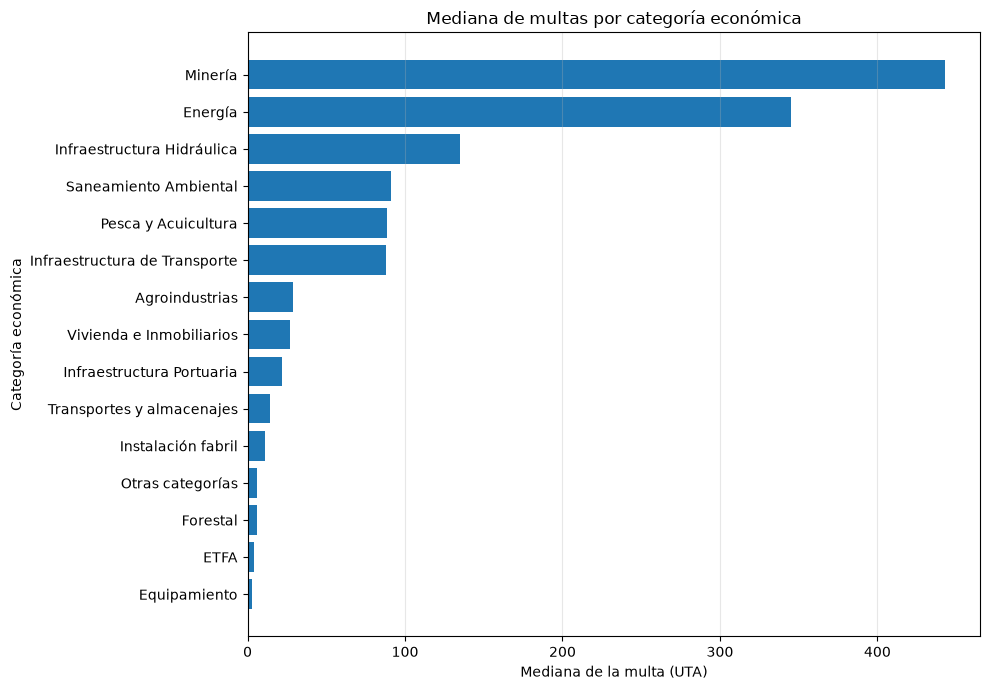

In [63]:
categoria_grafico = resumen_categoria.sort_values(
    "Multa_mediana",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    categoria_grafico["CategoriaEconomicaNombre"].astype(str),
    categoria_grafico["Multa_mediana"]
)

plt.xlabel("Mediana de la multa (UTA)")
plt.ylabel("Categoría económica")
plt.title("Mediana de multas por categoría económica")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### 20.1 Interpretación inicial

La comparación descriptiva muestra diferencias relevantes en la magnitud mediana de las multas entre categorías económicas. Minería y Energía presentan las medianas más elevadas dentro del conjunto analizado.

Sin embargo, estas diferencias deben interpretarse considerando simultáneamente el número de procedimientos de cada categoría y la fuerte asimetría de la distribución de las multas. Por lo tanto, estos resultados constituyen asociaciones descriptivas observadas en el conjunto de datos y no permiten establecer relaciones causales.

## 21. Validación final del conjunto de datos procesado

Antes de generar el conjunto de datos procesado se ejecutan verificaciones orientadas a comprobar la consistencia de las transformaciones realizadas durante la Fase 2.

Las validaciones consideran la conservación del número de registros, la unicidad del identificador del procedimiento, la ausencia de multas negativas, la consistencia de las coordenadas geográficas, la normalización de las regiones y la correcta conversión de las variables temporales.

Estas comprobaciones permiten detectar posibles errores introducidos durante el procesamiento y constituyen una evidencia reproducible de la calidad técnica del dataset resultante.

In [64]:
def validar_dataset(df, registros_originales):
    """
    Ejecuta validaciones básicas sobre el dataset procesado.
    Retorna un diccionario con los resultados.
    """
    
    resultados = {
        "Registros conservados":
            len(df) == registros_originales,
        
        "ID de procedimiento único":
            df["ProcesoSancionId"].is_unique,
        
        "Sin multas negativas":
            (df["MultaTotalUTA"].dropna() >= 0).all(),
        
        "Latitudes válidas":
            df["Latitud"].dropna().between(-90, 90).all(),
        
        "Longitudes válidas":
            df["Longitud"].dropna().between(-180, 180).all(),
        
        "Regiones normalizadas":
            df["RegionNombre"].nunique() == 16,
        
        "FechaInicio convertida":
            pd.api.types.is_datetime64_any_dtype(df["FechaInicio"]),
        
        "FechaTermino convertida":
            pd.api.types.is_datetime64_any_dtype(df["FechaTermino"])
    }
    
    return resultados

In [65]:
validaciones = validar_dataset(
    datos_procesados,
    registros_originales=len(datos_sancion)
)

print("=== VALIDACIÓN FINAL DEL DATASET ===\n")

for prueba, resultado in validaciones.items():
    estado = "OK" if resultado else "REVISAR"
    print(f"{prueba:<35} : {estado}")

=== VALIDACIÓN FINAL DEL DATASET ===

Registros conservados               : REVISAR
ID de procedimiento único           : REVISAR
Sin multas negativas                : OK
Latitudes válidas                   : OK
Longitudes válidas                  : OK
Regiones normalizadas               : OK
FechaInicio convertida              : OK
FechaTermino convertida             : OK


In [66]:
print("=== COMPARACIÓN DE REGISTROS ===")
print(f"datos_sancion      : {len(datos_sancion):,}")
print(f"datos_procesados   : {len(datos_procesados):,}")
print(f"Diferencia         : {len(datos_sancion) - len(datos_procesados):,}")

=== COMPARACIÓN DE REGISTROS ===
datos_sancion      : 1,094
datos_procesados   : 984
Diferencia         : 110


In [67]:
print("=== VALIDACIÓN DEL IDENTIFICADOR ===")

print(f"Total de registros          : {len(datos_procesados):,}")
print(f"IDs únicos                  : {datos_procesados['ProcesoSancionId'].nunique():,}")
print(f"IDs nulos                   : {datos_procesados['ProcesoSancionId'].isna().sum():,}")
print(f"Filas con ID duplicado      : {datos_procesados['ProcesoSancionId'].duplicated().sum():,}")

=== VALIDACIÓN DEL IDENTIFICADOR ===
Total de registros          : 984
IDs únicos                  : 963
IDs nulos                   : 0
Filas con ID duplicado      : 21


In [68]:
ids_duplicados = (
    datos_procesados[
        datos_procesados["ProcesoSancionId"].duplicated(keep=False)
    ]
    .sort_values("ProcesoSancionId")
)

ids_duplicados[
    [
        "ProcesoSancionId",
        "Expediente",
        "Nombre",
        "MultaTotalUTA",
        "RegionNombre",
        "CategoriaEconomicaNombre"
    ]
]

,ProcesoSancionId,Expediente,Nombre,MultaTotalUTA,RegionNombre,CategoriaEconomicaNombre
197,1192,F-002-2015,CES CANALAD 1 (RNA 110669),3142.0,Región de Aysén del General Carlos Ibáñez del ...,Pesca y Acuicultura
198,1192,F-002-2015,CES VALVERDE 5 (RNA 110688),3142.0,Región de Aysén del General Carlos Ibáñez del ...,Pesca y Acuicultura
199,1192,F-002-2015,CES LUNA 2 (RNA 110556),3142.0,Región de Aysén del General Carlos Ibáñez del ...,Pesca y Acuicultura
200,1192,F-002-2015,CES SENO VERA (RNA 110488),3142.0,Región de Aysén del General Carlos Ibáñez del ...,Pesca y Acuicultura
201,1192,F-002-2015,CES VALVERDE 1 (RNA 110524),3142.0,Región de Aysén del General Carlos Ibáñez del ...,Pesca y Acuicultura
202,1192,F-002-2015,CES VALVERDE 2 (RNA 110549),3142.0,Región de Aysén del General Carlos Ibáñez del ...,Pesca y Acuicultura
203,1192,F-002-2015,CES GRAFFER (RNA 110069),3142.0,Región de Aysén del General Carlos Ibáñez del ...,Pesca y Acuicultura
204,1192,F-002-2015,CES PUNTA PAREDES (RNA 110201),3142.0,Región de Aysén del General Carlos Ibáñez del ...,Pesca y Acuicultura
205,1192,F-002-2015,CES ESTERO SOTO (RNA 110060),3142.0,Región de Aysén del General Carlos Ibáñez del ...,Pesca y Acuicultura
206,1192,F-002-2015,CES SUR PUYUHUAPI (RNA 110839),3142.0,Región de Aysén del General Carlos Ibáñez del ...,Pesca y Acuicultura


### 22.1 Definición del universo analítico y granularidad de los datos

El conjunto correspondiente al estado `Terminado - Sanción` contiene 1.094 registros. De ellos, 984 presentan un valor informado en `MultaTotalUTA`, mientras que 110 no disponen de dicho valor.

Dado que la problemática del proyecto busca analizar factores asociados a la magnitud de las multas, se define para este análisis un universo de 984 registros con `MultaTotalUTA` disponible. Los 110 registros restantes no se eliminan del conjunto original, sino que quedan fuera de este universo analítico debido a que no permiten cuantificar la variable objetivo.

Adicionalmente, se verificó que los 984 registros contienen 963 valores únicos de `ProcesoSancionId`. La inspección de los identificadores repetidos mostró que estos no corresponden necesariamente a duplicados erróneos. Un mismo procedimiento sancionatorio puede estar asociado a más de una unidad fiscalizable o registro, manteniendo el mismo identificador de procedimiento.

Por esta razón, no se eliminan automáticamente los registros con `ProcesoSancionId` repetido. La granularidad de los datos se conserva y esta característica deberá considerarse en los análisis agregados para evitar otorgar un peso artificialmente mayor a procedimientos representados mediante múltiples registros.

In [69]:
def validar_dataset(df, registros_universo):
    """
    Ejecuta validaciones de consistencia sobre el dataset
    correspondiente al universo analítico.
    """

    resultados = {
        "Registros del universo analítico":
            len(df) == registros_universo,

        "IDs de procedimiento no nulos":
            df["ProcesoSancionId"].notna().all(),

        "Sin multas nulas":
            df["MultaTotalUTA"].notna().all(),

        "Sin multas negativas":
            (df["MultaTotalUTA"] >= 0).all(),

        "Latitudes válidas":
            df["Latitud"].dropna().between(-90, 90).all(),

        "Longitudes válidas":
            df["Longitud"].dropna().between(-180, 180).all(),

        "Regiones normalizadas":
            df["RegionNombre"].nunique() == 16,

        "FechaInicio convertida":
            pd.api.types.is_datetime64_any_dtype(df["FechaInicio"]),

        "FechaTermino convertida":
            pd.api.types.is_datetime64_any_dtype(df["FechaTermino"])
    }

    return resultados

In [70]:
registros_universo = datos_sancion["MultaTotalUTA"].notna().sum()

validaciones = validar_dataset(
    datos_procesados,
    registros_universo=registros_universo
)

print("=== VALIDACIÓN FINAL DEL DATASET ===\n")

for prueba, resultado in validaciones.items():
    estado = "OK" if resultado else "REVISAR"
    print(f"{prueba:<35} : {estado}")

=== VALIDACIÓN FINAL DEL DATASET ===

Registros del universo analítico    : OK
IDs de procedimiento no nulos       : OK
Sin multas nulas                    : OK
Sin multas negativas                : OK
Latitudes válidas                   : OK
Longitudes válidas                  : OK
Regiones normalizadas               : OK
FechaInicio convertida              : OK
FechaTermino convertida             : OK


In [71]:
revision_procedimientos = (
    datos_procesados
    .groupby("ProcesoSancionId", observed=True)
    .agg(
        Registros=("ProcesoSancionId", "size"),
        Expedientes=("Expediente", "nunique"),
        Valores_multa=("MultaTotalUTA", "nunique"),
        MultaTotalUTA=("MultaTotalUTA", "first")
    )
    .query("Registros > 1")
    .sort_values("Registros", ascending=False)
)

revision_procedimientos

,Registros,Expedientes,Valores_multa,MultaTotalUTA
ProcesoSancionId,,,,
1192,18,1,1,3142.0
1569,3,1,1,1006.0
1471,2,1,1,19.0
2610,2,1,1,4.2


### 22.2 Verificación de procedimientos representados en múltiples registros

La revisión de los identificadores repetidos confirmó cuatro procedimientos representados mediante múltiples registros. En todos los casos, los registros asociados a un mismo `ProcesoSancionId` corresponden a un único expediente y presentan un único valor de `MultaTotalUTA`.

El caso de mayor multiplicidad corresponde al procedimiento 1192, representado mediante 18 registros asociados a distintas unidades fiscalizables, pero con un mismo expediente y una multa total de 3.142 UTA.

Por lo tanto, estos registros no se consideran duplicados erróneos y se conservan en el conjunto procesado. Sin embargo, esta granularidad debe ser considerada en los análisis posteriores: cuando la unidad de análisis corresponda al procedimiento sancionatorio, se deberá utilizar una vista consolidada a nivel de `ProcesoSancionId` para evitar que un procedimiento representado mediante múltiples unidades fiscalizables tenga una ponderación artificialmente mayor.

## 23. Exportación del conjunto de datos procesado

Una vez completadas las transformaciones y validaciones, se genera una copia procesada del conjunto de datos en `data/processed/`.

El archivo original almacenado en `data/raw/` permanece inalterado. Esta separación permite mantener trazabilidad entre la fuente original y el resultado del pipeline de Fase 2.

El archivo procesado contiene exclusivamente el universo analítico definido para el estudio y las transformaciones documentadas en este notebook.

In [72]:
from pathlib import Path

RUTA_PROCESADOS = Path("../data/processed")
RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)

ARCHIVO_SALIDA = RUTA_PROCESADOS / "sancionatorios_procesados.csv"

datos_procesados.to_csv(
    ARCHIVO_SALIDA,
    index=False,
    encoding="utf-8-sig"
)

print("=== EXPORTACIÓN DEL DATASET ===")
print(f"Archivo generado : {ARCHIVO_SALIDA}")
print(f"Registros        : {len(datos_procesados):,}")
print(f"Variables        : {datos_procesados.shape[1]}")
print(f"Existe archivo   : {ARCHIVO_SALIDA.exists()}")

=== EXPORTACIÓN DEL DATASET ===
Archivo generado : ..\data\processed\sancionatorios_procesados.csv
Registros        : 984
Variables        : 20
Existe archivo   : True


In [73]:
datos_verificacion = pd.read_csv(ARCHIVO_SALIDA)

print("=== VERIFICACIÓN DEL ARCHIVO EXPORTADO ===")
print(f"Archivo legible       : OK")
print(f"Registros exportados  : {len(datos_verificacion):,}")
print(f"Variables exportadas  : {datos_verificacion.shape[1]}")
print(
    "Mismo número de filas:",
    len(datos_verificacion) == len(datos_procesados)
)
print(
    "Mismo número de columnas:",
    datos_verificacion.shape[1] == datos_procesados.shape[1]
)

=== VERIFICACIÓN DEL ARCHIVO EXPORTADO ===
Archivo legible       : OK
Registros exportados  : 984
Variables exportadas  : 20
Mismo número de filas: True
Mismo número de columnas: True


## 24. Registro de decisiones de procesamiento

Durante la Fase 2 se adoptaron las siguientes decisiones técnicas a partir de la exploración y validación del conjunto de datos:

1. **Definición del universo analítico.**  
   El análisis de magnitud de multas se restringe a procedimientos con estado `Terminado - Sanción` y con un valor informado en `MultaTotalUTA`. De los 1.094 procedimientos terminados con sanción, 984 poseen un valor de multa disponible y constituyen el universo analítico utilizado.

2. **Tratamiento de valores nulos en MultaTotalUTA.**  
   Los valores ausentes no fueron imputados con cero, debido a que ausencia de información y multa igual a cero representan situaciones conceptualmente diferentes. Los 110 registros sin valor de multa se excluyen del análisis de magnitud, pero esta decisión queda documentada para mantener la trazabilidad del proceso.

3. **Valores extremos de las multas.**  
   Los valores identificados mediante el criterio IQR no fueron eliminados automáticamente. Se observaron 149 valores potencialmente atípicos, equivalentes al 15,14 % de los registros analizados. Estos pueden corresponder a sanciones reales de gran magnitud y son relevantes para la problemática estudiada.

4. **Medida descriptiva principal.**  
   Debido a la fuerte asimetría positiva de `MultaTotalUTA`, se utiliza la mediana como medida principal para comparar la magnitud típica de las multas entre grupos. El promedio y el máximo se conservan como medidas complementarias.

5. **Normalización de regiones.**  
   Se detectaron variantes de escritura para las regiones de La Araucanía y Los Lagos. Estas categorías fueron normalizadas, obteniéndose las 16 regiones del país.

6. **Variables temporales.**  
   `FechaInicio`, `FechaTermino` y `FechaActualizacion` fueron convertidas a formato de fecha. A partir de las fechas de inicio y término se generó `DuracionDias`, conservando como ausentes los casos en que no fue posible calcular la duración.

7. **Variables categóricas.**  
   Las variables nominales relevantes para el análisis fueron convertidas al tipo `category`. Su naturaleza conceptual prevalece sobre una clasificación automática basada únicamente en cardinalidad.

8. **Conservación del dato original.**  
   El archivo descargado el 09-09-2026 se mantiene sin modificaciones en `data/raw/`. Las transformaciones se realizan sobre una copia y el resultado se almacena separadamente en `data/processed/`.

Estas decisiones constituyen el registro técnico del procesamiento y permiten relacionar cada transformación con una justificación explícita. Junto con el código ejecutable, el entorno documentado, el README y el historial de commits de Git, contribuyen a la trazabilidad y reproducibilidad del proyecto.

## 25. Cierre de la Fase 2

La Fase 2 permitió transformar el conjunto de datos original en un conjunto preparado y validado para las etapas posteriores del proyecto.

A partir de los 3.537 registros originales, se identificaron 1.094 procedimientos con estado `Terminado - Sanción`. De ellos, 984 cuentan con un valor informado de `MultaTotalUTA` y conforman el universo analítico para estudiar los factores asociados a la magnitud de las multas.

El procesamiento incluyó la conversión de variables temporales, normalización de categorías regionales, clasificación de variables categóricas, generación de `DuracionDias`, evaluación de valores ausentes y revisión de posibles valores atípicos. Las validaciones finales confirman la consistencia estructural del conjunto procesado de acuerdo con los criterios definidos.

La exploración evidencia además una marcada asimetría positiva en `MultaTotalUTA`, por lo que se definió la mediana como medida descriptiva principal para las comparaciones entre grupos, sin eliminar automáticamente las sanciones de gran magnitud.

Como resultado de esta fase se genera `data/processed/sancionatorios_procesados.csv`, manteniendo sin modificaciones la copia original descargada el 09-09-2026 en `data/raw/`.

Las decisiones adoptadas quedan documentadas en las celdas narrativas del notebook; el código conserva las transformaciones y validaciones ejecutadas; Git registra la evolución de estos cambios; y el README documentará las instrucciones necesarias para reproducir el flujo de trabajo.

De esta forma, el proyecto mantiene separados pero relacionados tres componentes fundamentales: **reproducibilidad del entorno y la ejecución, trazabilidad de los cambios y documentación de las decisiones técnicas**.